# Table of Contents

- Initial code
- Data Generation and Visualization
- Data Splitting
- Initial KNN Model and Evaluation
- Hyperparameter Tuning with GridSearchCV
- Evaluating the Best Model
- Validation Curve Plot
- kNN vs Noise
- Decision Tree vs Noise
- SVM vs Noise
- Plotting Decision Boundaries





---



In [ ]:
# -------------------------------
# Code Documentation & Package Versions
# -------------------------------
import sys
import platform
import pkgutil

import numpy as np
import pandas as pd
import sklearn
import matplotlib
import seaborn as sns
import joblib
# Printing versions of Python and main libraries to ensure reproducibility
print("python:", sys.version.splitlines()[0])
print("platform:", platform.platform())
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("joblib:", joblib.__version__)

python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
platform: Linux-6.6.105+-x86_64-with-glibc2.35
numpy: 2.0.2
pandas: 2.2.2
scikit-learn: 1.6.1
matplotlib: 3.10.0
seaborn: 0.13.2
joblib: 1.5.2


In [ ]:
# Installing specific library versions to avoid inconsistencies
!pip install numpy==2.0.2
!pip install pandas==2.2.2
!pip install scikit-learn==1.6.1
!pip install matplotlib==3.10.0
!pip install seaborn==0.13.2
!pip install joblib==1.5.2



---



### Initial code

showing the whole workflow in details before comparing the models' behaviour against noise to establish the baseline understanding

### Data Generation and Visualization


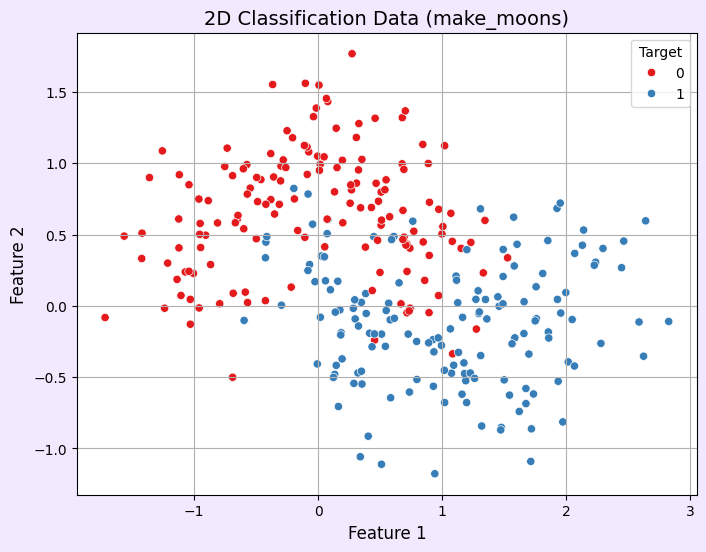

In [ ]:
# -------------------------------
# Importing libraries
# -------------------------------
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, validation_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# -------------------------------
# Generating synthetic 2D dataset (make_moons)
# -------------------------------
# This dataset is nonlinear and ideal for testing non-linear classifiers like kNN, SVM, and Decision Trees
X, y = make_moons(n_samples=300, noise=0.3, random_state=42) # <- change the noise!

# Creating a DataFrame for visualization convenience
df = pd.DataFrame(X, columns=["Feature 1", "Feature 2"])
df['Target'] = y

# Visualizing the data
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue="Target", palette="Set1")
plt.title("2D Classification Data (make_moons)")
plt.grid(True)
plt.show()

### Data Splitting


In [ ]:
# -------------------------------
# Split Dataset into Train/Validation/Test
# -------------------------------
# Training gets 80% to learn patterns
# Validation + Test (20%) ensures unbiased evaluation and hyperparameter tuning

x_train, x_combined, y_train, y_combined = train_test_split(X, y, train_size=0.8, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_combined, y_combined, test_size=0.5, random_state=42)

# Combine train + validation for hyperparameter tuning via GridSearchCV
# GridSearchCV internally splits data for cross-validation

x_train_val = np.vstack([x_train, x_val])
y_train_val = np.hstack([y_train, y_val])

### Initial KNN Model and Evaluation


In [ ]:
# Start with a reasonable default to test basic model performance
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
# Evaluate initial performance on the test set
# Provides a baseline before tuning k
y_pred = knn.predict(x_test)
print(f"Test Accuracy (k=5): {accuracy_score(y_test, y_pred):.2f}")
# Small noise makes classes more separable; accuracy can be near perfect
# With higher noise, initial k may overfit or underfit, motivating hyperparameter search

Test Accuracy (k=5): 1.00


### Hyperparameter Tuning with GridSearchCV


In [ ]:
# -------------------------------
# GridSearchCV to Find Optimal k
# -------------------------------

'''
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': [20, 30, 40],
    'p': [1, 2],  # p=1 for Manhattan, p=2 for Euclidean in Minkowski
    'metric': ['minkowski', 'manhattan', 'euclidean']
}  '''

# Focus on n_neighbors only as the main regularization parameter for kNN
# Avoid even numbers to reduce the risk of ties in majority voting

param_grid = {'n_neighbors': [1,3, 5, 7, 9,11,13,15,17,19]} # eliminate even numbers to prevent ties!
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, n_jobs=-1)

# Fit GridSearchCV on train+validation data to find k that balances bias-variance tradeoff

grid_search.fit(x_train_val, y_train_val)

# Report best hyperparameter and cross-validation score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'n_neighbors': 7}
Best cross-validation score: 0.9037037037037038


### Evaluating the Best Model


In [ ]:
# -------------------------------
# Cross-Validation with Best k
# -------------------------------
best_params = grid_search.best_params_
knn_best = KNeighborsClassifier(**best_params)

# 5-fold CV on training set ensures that selected k generalizes well
cv_scores_best_model = cross_val_score(knn_best, x_train, y_train, cv=5, scoring='accuracy')

print(f"Cross-validation accuracy for the best model (using GridSearchCV parameters): {cv_scores_best_model.mean():.4f}")
print(f"Individual cross-validation scores: {cv_scores_best_model}")

Cross-validation accuracy for the best model (using GridSearchCV parameters): 0.9042
Individual cross-validation scores: [0.9375     0.9375     0.85416667 0.91666667 0.875     ]


### Validation Curve Plot


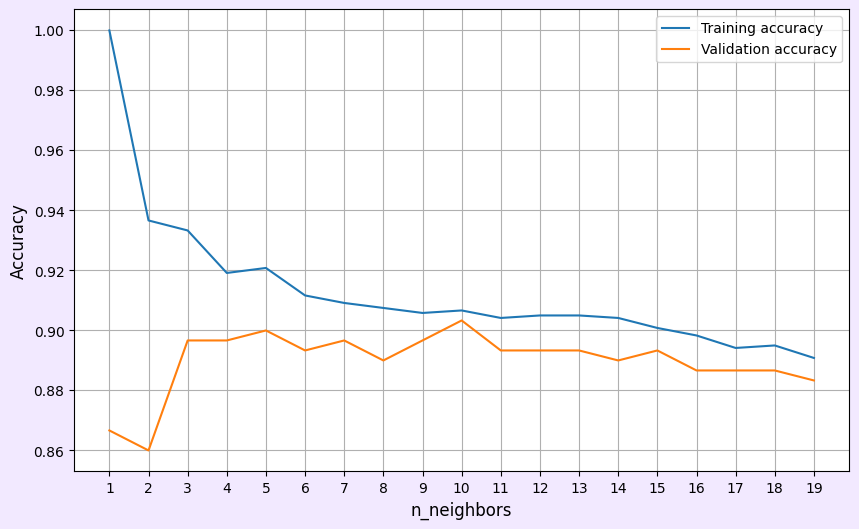

In [ ]:
# -------------------------------
# Validation Curve to Visualize k Effect
# -------------------------------

param_range = np.arange(1, 20)
train_scores, val_scores = validation_curve(
    KNeighborsClassifier(),
    X, y,
    param_name="n_neighbors",
    param_range=param_range,
    cv=5,
    scoring="accuracy"
)

mean_train = np.mean(train_scores, axis=1)
mean_val = np.mean(val_scores, axis=1)

# Plot training vs validation accuracy to observe overfitting/underfitting trends
plt.plot(param_range, mean_train, label="Training accuracy")
plt.plot(param_range, mean_val, label="Validation accuracy")
plt.xlabel("n_neighbors")
plt.ylabel("Accuracy")
plt.xticks(param_range)
plt.legend()
plt.show()
# Observing the gap between training and validation accuracy shows regularization effect of k



---


---



---




### kNN vs Noise


In [ ]:
def find_optimal_k_for_noise(noise_level, k_range=np.arange(1, 20)):
    """
    Generates a make_moons dataset with the specified noise level,
    finds the optimal k using GridSearchCV, evaluates on the test set.
    """
    # Generate larger dataset for more stable results
    X, y = make_moons(n_samples=3000, noise=noise_level, random_state=42)

    # Split into train, validation, test
    x_train, x_combined, y_train, y_combined = train_test_split(X, y, train_size=0.8, random_state=42)
    x_val, x_test, y_val, y_test = train_test_split(x_combined, y_combined, test_size=0.5, random_state=42)
    x_train_val = np.vstack([x_train, x_val])
    y_train_val = np.hstack([y_train, y_val])

    # Grid search for n_neighbors to control model complexity (regularization)
    param_grid = {'n_neighbors': k_range}
    knn = KNeighborsClassifier()
    grid_search = GridSearchCV(knn, param_grid, cv=5, n_jobs=-1)
    grid_search.fit(x_train_val, y_train_val)

    # Evaluate on test set to check generalization
    best_k = grid_search.best_params_['n_neighbors']
    knn_best = KNeighborsClassifier(n_neighbors=best_k)
    knn_best.fit(x_train_val, y_train_val)
    test_score = knn_best.score(x_test, y_test)

    return best_k, test_score

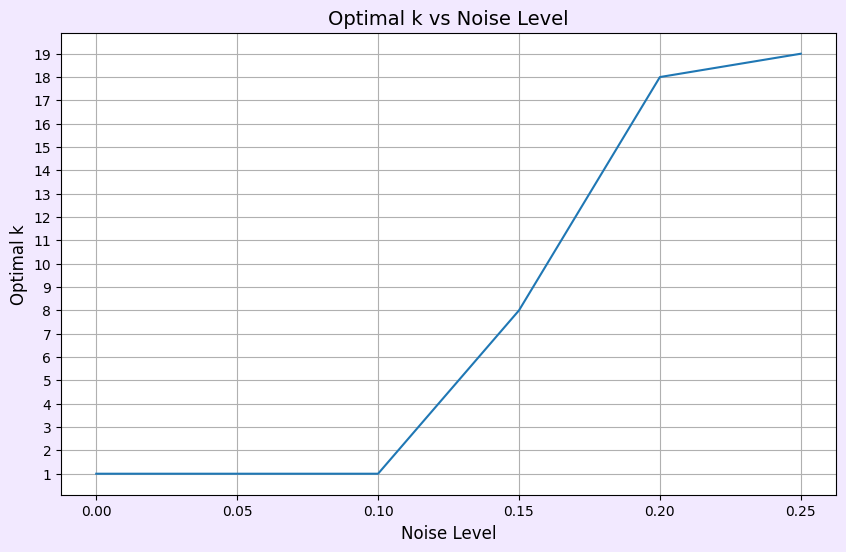

In [ ]:
noise_levels = np.arange(0.0, 0.3, 0.05)
optimal_ks = []

for noise in noise_levels:
    best_k, test_score = find_optimal_k_for_noise(noise)
    optimal_ks.append(best_k)

# Plot trend: shows how noise pushes k higher (stronger regularization)
plt.figure(figsize=(10, 6))
plt.plot(noise_levels, optimal_ks)
plt.xlabel("Noise Level")
plt.ylabel("Optimal k")
plt.xticks(noise_levels)
plt.yticks(np.arange(1, 20))
plt.title("Optimal k vs Noise Level")
plt.rcParams['figure.facecolor'] = '#EED0EC'
plt.show()



---



### Decision Tree vs Noise


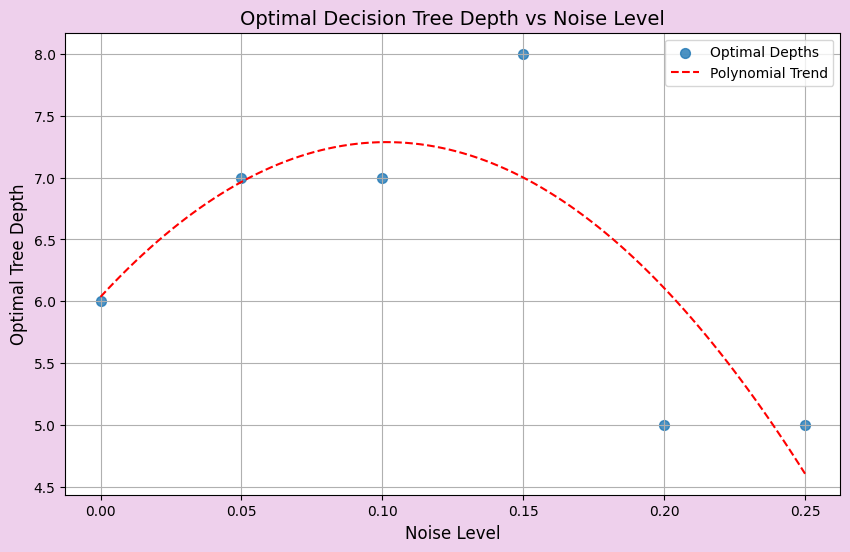

In [ ]:
def find_optimal_depth_for_noise(noise_level, depth_range=np.arange(1, 20)):
    """
    Generate make_moons with given noise, tune max_depth via GridSearchCV,
    and evaluate test accuracy.
    """
    X, y = make_moons(n_samples=3000, noise=noise_level, random_state=42)
    x_train, x_combined, y_train, y_combined = train_test_split(X, y, train_size=0.8, random_state=42)
    x_val, x_test, y_val, y_test = train_test_split(x_combined, y_combined, test_size=0.5, random_state=42)
    x_train_val = np.vstack([x_train, x_val])
    y_train_val = np.hstack([y_train, y_val])

    param_grid = {'max_depth': depth_range}
    dt = DecisionTreeClassifier(random_state=42)
    grid_search = GridSearchCV(dt, param_grid, cv=5, n_jobs=-1)
    grid_search.fit(x_train_val, y_train_val)

    best_depth = grid_search.best_params_['max_depth']
    dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
    dt_best.fit(x_train_val, y_train_val)
    test_score = dt_best.score(x_test, y_test)

    return best_depth, test_score

optimal_depths = []
for noise in noise_levels:
    best_depth, test_score = find_optimal_depth_for_noise(noise)
    optimal_depths.append(best_depth)

# Plot trend: higher noise → lower max_depth to prevent overfitting
plt.figure(figsize=(10, 6)) # Set figure size to match other plots
plt.scatter(noise_levels, optimal_depths, s=50, alpha=0.8, label="Optimal Depths")
poly_coeffs = np.polyfit(noise_levels, optimal_depths, 2)
x_trend = np.linspace(noise_levels.min(), noise_levels.max(), 100)
y_trend = np.polyval(poly_coeffs, x_trend)
plt.plot(x_trend, y_trend, color='red', linestyle='--', label="Polynomial Trend")
plt.xlabel("Noise Level")
plt.ylabel("Optimal Tree Depth")
plt.xticks(noise_levels)
plt.title("Optimal Decision Tree Depth vs Noise Level")
plt.grid(True)
plt.legend()
plt.show()



---



### SVM vs Noise


In [ ]:
def find_optimal_svm_params_for_noise(noise_level, c_range=np.logspace(-1, 1, 3)):
    """
    Generate make_moons with given noise, tune C (inverse regularization) using GridSearchCV,
    and evaluate test accuracy.
    """
    X, y = make_moons(n_samples=3000, noise=noise_level, random_state=42)
    x_train, x_combined, y_train, y_combined = train_test_split(X, y, train_size=0.8, random_state=42)
    x_val, x_test, y_val, y_test = train_test_split(x_combined, y_combined, test_size=0.5, random_state=42)
    x_train_val = np.vstack([x_train, x_val])
    y_train_val = np.hstack([y_train, y_val])

    param_grid = {'C': c_range, 'kernel': ['rbf']}
    svc = SVC(random_state=42)
    grid_search = GridSearchCV(svc, param_grid, cv=5, n_jobs=-1)
    grid_search.fit(x_train_val, y_train_val)

    best_params = grid_search.best_params_
    svc_best = SVC(**best_params, random_state=42)
    svc_best.fit(x_train_val, y_train_val)
    test_score = svc_best.score(x_test, y_test)

    return best_params, test_score

,noise_level,best_C,best_kernel,test_score
0,0.00,0.1,rbf,1.000000
1,0.05,0.1,rbf,1.000000
2,0.10,10.0,rbf,1.000000
3,0.15,10.0,rbf,0.996667
4,0.20,1.0,rbf,0.966667
5,0.25,1.0,rbf,0.930000


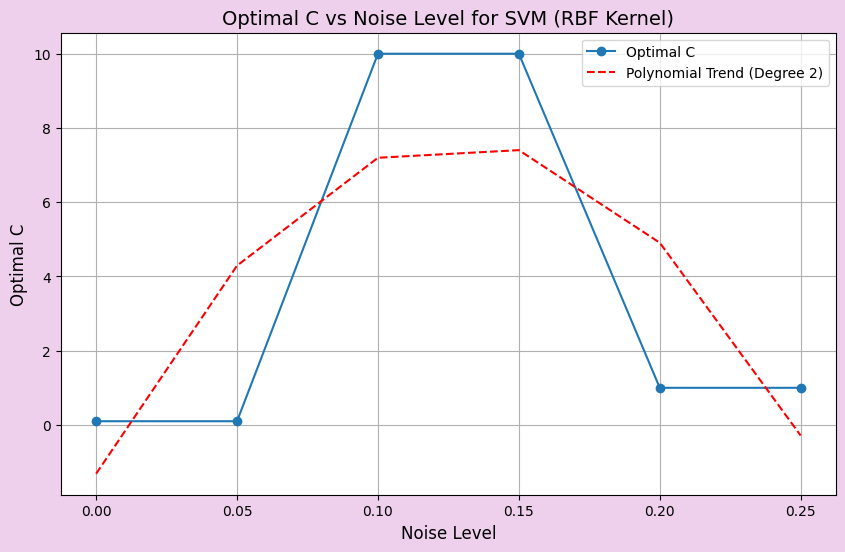

In [ ]:
optimal_results = []
for noise in noise_levels:
    best_params, test_score = find_optimal_svm_params_for_noise(noise)
    optimal_results.append({
        'noise_level': noise,
        'best_C': best_params['C'],
        'best_kernel': best_params['kernel'],
        'test_score': test_score
    })

results_df = pd.DataFrame(optimal_results)
display(results_df)

# Plot SVM optimal C trend: larger noise → smaller C (stronger regularization)
plt.figure(figsize=(10, 6))
plt.plot(results_df['noise_level'], results_df['best_C'], marker='o', label='Optimal C')
degree = 2
coefficients_c = np.polyfit(results_df['noise_level'], results_df['best_C'], degree)
polynomial_c = np.poly1d(coefficients_c)
plt.plot(results_df['noise_level'], polynomial_c(results_df['noise_level']), linestyle='--', color='red', label=f'Polynomial Trend (Degree {degree})')
plt.xlabel("Noise Level")
plt.ylabel("Optimal C")
plt.title("Optimal C vs Noise Level for SVM (RBF Kernel)")
plt.xticks(noise_levels)
plt.grid(True)
plt.legend()
plt.rcParams['figure.facecolor'] = '#EED0EC'
plt.show()


<h3 id="plotting-decision-boundaries">Plotting Decision Boundaries</h3>




Now, let's visualize the decision boundaries for the SVM classifier at different noise levels (0.05, 0.15, 0.25). We will use the optimal `C` parameter found for each noise level to train the SVM and then plot its decision boundary over the generated data.

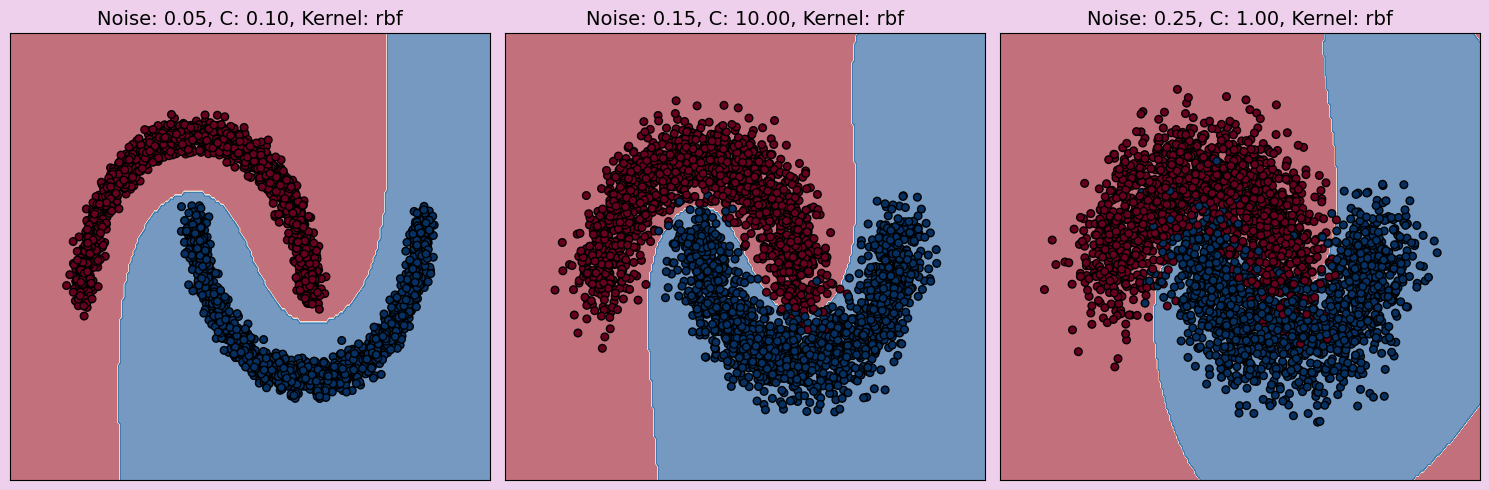

In [ ]:
def plot_decision_boundary(model, X, y, ax, title):
    """
    Plot the SVM decision boundary along with data points.
    Shows visually how noise affects boundary complexity and regularization.
    """
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.02  # step size in the mesh

    # Generate a meshgrid of points to plot decision boundary
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.6)

    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, s=30, edgecolors='k')
    ax.set_title(title)
    ax.set_xticks(())
    ax.set_yticks(())

# Define the noise levels to plot
plot_noise_levels = [0.05, 0.15, 0.25]

plt.figure(figsize=(15, 5))

for i, noise_level in enumerate(plot_noise_levels):
    # Get optimal parameters for this noise level from results_df
    # Use np.isclose for robust float comparison
    optimal_row = results_df[np.isclose(results_df['noise_level'], noise_level)].iloc[0]
    best_C = optimal_row['best_C']
    best_kernel = optimal_row['best_kernel']

    # Generate data for this noise level
    X, y = make_moons(n_samples=3000, noise=noise_level, random_state=42)

    # Train SVM with optimal parameters
    svm_model = SVC(C=best_C, kernel=best_kernel, random_state=42)
    svm_model.fit(X, y)

    # Create subplot and plot decision boundary
    ax = plt.subplot(1, len(plot_noise_levels), i + 1)
    title = f"Noise: {noise_level}, C: {best_C:.2f}, Kernel: {best_kernel}"
    plot_decision_boundary(svm_model, X, y, ax, title)

plt.tight_layout()
plt.rcParams['figure.facecolor'] = '#EED0EC'
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Configure global Matplotlib parameters
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.facecolor'] = 'F2E9FF'

print("Global Matplotlib plotting parameters set.")

Global Matplotlib plotting parameters set.
